# Phase 2 — Fraud Pattern Mining
## Association Rule Mining + Isolation Forest Baseline

**EDA key decisions (from Phase 1):**
- Core discriminative features: `amt`, `hour/night`, `category`
- Drop from rule mining: `distance_km` (AUC=0.501), `city_pop` (AUC=0.508)
- Fraud rate: 0.5210% — lift > 2x baseline already meaningful
- Cross-feature signal: `shopping_net × night` = 4.2% fraud (8x baseline)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              average_precision_score)
from mlxtend.frequent_patterns import fpgrowth, association_rules

import os
FIG_DIR   = '../outputs/figures/'
RULES_DIR = '../outputs/rules/'
os.makedirs(RULES_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Setup OK')

Setup OK


---
## 2.1 Load Data & Verify Features

In [2]:
df = pd.read_csv('../data/processed/transactions_with_features.csv')

# Overall constants
N_TOTAL        = len(df)
N_FRAUD        = df['is_fraud'].sum()
FRAUD_RATE     = df['is_fraud'].mean()          # 0.00521
y_true         = df['is_fraud'].values
fraud_mask     = df['is_fraud'] == 1
nonfraud_mask  = df['is_fraud'] == 0

print(f'Total transactions : {N_TOTAL:,}')
print(f'Fraud              : {N_FRAUD:,} ({FRAUD_RATE*100:.4f}%)')
print(f'Non-fraud          : {N_TOTAL - N_FRAUD:,}')
print(f'\nDerived features available: {[c for c in df.columns if c in ["hour_of_day","day_of_week","month","distance_km","age"]]}')

Total transactions : 1,852,394
Fraud              : 9,651 (0.5210%)
Non-fraud          : 1,842,743

Derived features available: ['hour_of_day', 'day_of_week', 'month', 'distance_km', 'age']


In [3]:
# ── Re-discretize with clean labels for ARM (dropping distance_km & city_pop) ─
def amt_bin(a):
    if a < 50:   return 'amt_low'
    if a < 200:  return 'amt_medium'
    if a < 500:  return 'amt_high'
    return 'amt_very_high'

def time_bin(h):
    if h >= 22 or h < 6: return 'time_night'
    if h < 12:            return 'time_morning'
    if h < 18:            return 'time_afternoon'
    return 'time_evening'

def age_bin(a):
    if a < 30: return 'age_young'
    if a < 55: return 'age_middle'
    return 'age_senior'

df['amt_item']  = df['amt'].apply(amt_bin)
df['time_item'] = df['hour_of_day'].apply(time_bin)
df['age_item']  = df['age'].apply(age_bin)
df['cat_item']  = 'cat_' + df['category']

# Verify bin distributions
print('── Amount bins ──')
print(df.groupby('amt_item')['is_fraud'].agg(['mean','count']).assign(
    fraud_rate_pct=lambda x: x['mean']*100).round(2)[['fraud_rate_pct','count']])

print('\n── Time bins ──')
print(df.groupby('time_item')['is_fraud'].agg(['mean','count']).assign(
    fraud_rate_pct=lambda x: x['mean']*100).round(2)[['fraud_rate_pct','count']])

print('\n── Age bins ──')
print(df.groupby('age_item')['is_fraud'].agg(['mean','count']).assign(
    fraud_rate_pct=lambda x: x['mean']*100).round(2)[['fraud_rate_pct','count']])

── Amount bins ──
               fraud_rate_pct   count
amt_item                             
amt_high                 4.01   65574
amt_low                  0.22  961097
amt_medium               0.03  804014
amt_very_high           21.58   21709

── Time bins ──


                fraud_rate_pct   count
time_item                             
time_afternoon            0.10  561117
time_evening              0.11  374304
time_morning              0.10  361926
time_night                1.50  555047

── Age bins ──
            fraud_rate_pct   count
age_item                          
age_middle            0.45  996926
age_senior            0.67  517345
age_young             0.52  338123


---
## 2.2 One-Hot Encoding for FP-Growth

In [4]:
# One-hot encode items — boolean DataFrame required by mlxtend fpgrowth
cat_dummies  = pd.get_dummies(df['cat_item'],  dtype=bool)
amt_dummies  = pd.get_dummies(df['amt_item'],  dtype=bool)
time_dummies = pd.get_dummies(df['time_item'], dtype=bool)
age_dummies  = pd.get_dummies(df['age_item'],  dtype=bool)

df_enc = pd.concat([cat_dummies, amt_dummies, time_dummies, age_dummies], axis=1)
df_enc['fraud_yes'] = (df['is_fraud'] == 1)

ITEMS = list(df_enc.columns)
print(f'Encoded DataFrame: {df_enc.shape}')
print(f'Items ({len(ITEMS)}): {ITEMS}')
print(f'Memory: {df_enc.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Encoded DataFrame: (1852394, 26)
Items (26): ['cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel', 'amt_high', 'amt_low', 'amt_medium', 'amt_very_high', 'time_afternoon', 'time_evening', 'time_morning', 'time_night', 'age_middle', 'age_senior', 'age_young', 'fraud_yes']
Memory: 48.2 MB


Item frequency in fraud vs non-fraud (top items by ratio):
                   fraud_%  nonfraud_%  ratio
fraud_yes           100.00        0.00    inf
amt_very_high        48.53        0.92  52.53
amt_high             27.26        3.42   7.98
cat_shopping_net     22.99        7.44   3.09
time_night           86.11       29.67   2.90
cat_misc_net         12.25        4.86   2.52
cat_grocery_pos      23.09        9.44   2.45
age_senior           35.74       27.89   1.28
cat_shopping_pos     10.94        8.98   1.22
age_young            18.27       18.25   1.00
age_middle           46.00       53.86   0.85
cat_gas_transport     8.00       10.16   0.79
cat_misc_pos          3.34        6.18   0.54
cat_travel            1.62        3.14   0.52
cat_grocery_net       1.81        3.51   0.52


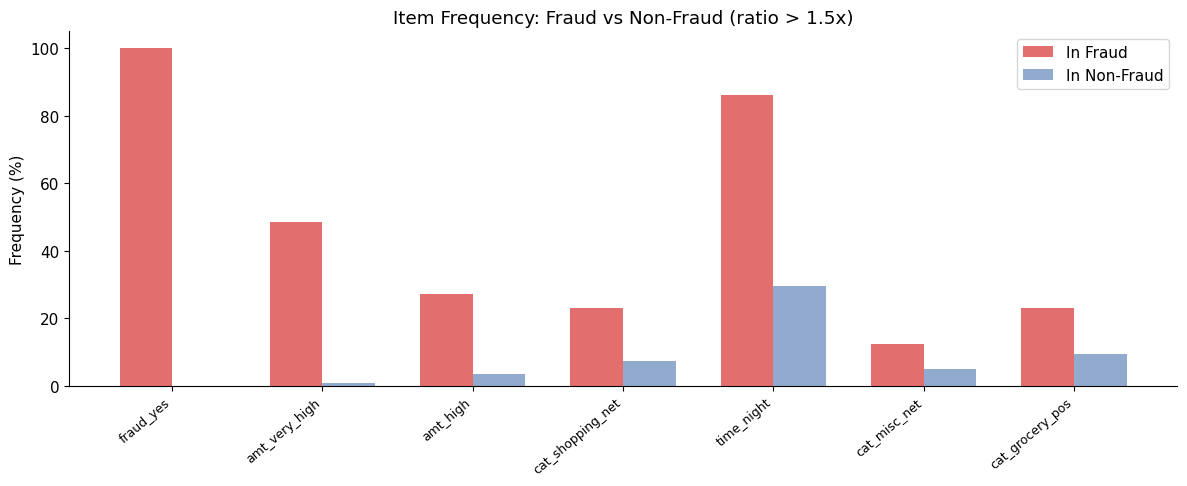

In [5]:
# Item frequency comparison: fraud vs non-fraud
fraud_freq    = df_enc[fraud_mask].mean() * 100
nonfraud_freq = df_enc[nonfraud_mask].mean() * 100

item_compare = pd.DataFrame({
    'fraud_%'   : fraud_freq.round(2),
    'nonfraud_%': nonfraud_freq.round(2),
    'ratio'     : (fraud_freq / nonfraud_freq).round(2)
}).sort_values('ratio', ascending=False)

print('Item frequency in fraud vs non-fraud (top items by ratio):')
print(item_compare.head(15).to_string())

# Visualize top discriminative items
top = item_compare[item_compare['ratio'] > 1.5].head(15)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top))
w = 0.35
ax.bar(x - w/2, top['fraud_%'],    w, label='In Fraud',     color='#DD5555', alpha=0.85)
ax.bar(x + w/2, top['nonfraud_%'], w, label='In Non-Fraud', color='#4C72B0', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(top.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Frequency (%)')
ax.set_title('Item Frequency: Fraud vs Non-Fraud (ratio > 1.5x)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '19_item_frequency.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2.3 Baseline 1 — Simple Threshold: amt > $500

In [6]:
y_pred_thresh = (df['amt'] > 500).astype(int).values

prec_t  = precision_score(y_true, y_pred_thresh)
rec_t   = recall_score(y_true, y_pred_thresh)
f1_t    = f1_score(y_true, y_pred_thresh)
ap_t    = average_precision_score(y_true, y_pred_thresh)
n_flag  = y_pred_thresh.sum()
tp_t    = ((y_pred_thresh == 1) & (y_true == 1)).sum()
fp_t    = ((y_pred_thresh == 1) & (y_true == 0)).sum()

print('── Baseline 1: amt > $500 ──')
print(f'Transactions flagged : {n_flag:,} ({n_flag/N_TOTAL*100:.2f}% of all)')
print(f'True Positives       : {tp_t:,} / {N_FRAUD:,} fraud ({tp_t/N_FRAUD*100:.1f}% recall)')
print(f'False Positives      : {fp_t:,}')
print(f'Precision            : {prec_t:.4f} ({prec_t*100:.2f}%)')
print(f'Recall               : {rec_t:.4f} ({rec_t*100:.2f}%)')
print(f'F1-Score             : {f1_t:.4f}')
print(f'AUC-PR               : {ap_t:.4f}')

── Baseline 1: amt > $500 ──
Transactions flagged : 21,709 (1.17% of all)
True Positives       : 4,684 / 9,651 fraud (48.5% recall)
False Positives      : 17,025
Precision            : 0.2158 (21.58%)
Recall               : 0.4853 (48.53%)
F1-Score             : 0.2987
AUC-PR               : 0.1074


---
## 2.4 Baseline 2 — Isolation Forest

In [7]:
# Use all 5 features as specified in plan
# Note: distance_km & city_pop have low AUC per EDA but kept for IF comparison
features_if = ['amt', 'distance_km', 'city_pop', 'age', 'hour_of_day']
X = df[features_if].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

contamination_values = [0.005, 0.01, 0.02]
if_results = []

for cont in contamination_values:
    print(f'  Training IF contamination={cont}...', end=' ')
    t0  = time.time()
    clf = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    raw = clf.fit_predict(X_sc)
    y_pred_if = (raw == -1).astype(int)
    dt  = time.time() - t0

    prec = precision_score(y_true, y_pred_if)
    rec  = recall_score(y_true, y_pred_if)
    f1   = f1_score(y_true, y_pred_if)
    ap   = average_precision_score(y_true, y_pred_if)
    n_fl = y_pred_if.sum()
    tp   = ((y_pred_if == 1) & (y_true == 1)).sum()

    if_results.append({'contamination': cont, 'precision': prec, 'recall': rec,
                        'f1': f1, 'ap': ap, 'n_flagged': n_fl, 'tp': tp,
                        'pred': y_pred_if.copy()})
    print(f'done ({dt:.0f}s) | P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}  flagged={n_fl:,}')

# Best by F1
best_if_idx = max(range(len(if_results)), key=lambda i: if_results[i]['f1'])
best_if     = if_results[best_if_idx]
y_pred_if_best = best_if['pred']
print(f'\nBest IF: contamination={best_if["contamination"]}  F1={best_if["f1"]:.4f}')

  Training IF contamination=0.005... 

done (19s) | P=0.1974  R=0.1894  F1=0.1933  flagged=9,262
  Training IF contamination=0.01... 

done (16s) | P=0.1704  R=0.3270  F1=0.2240  flagged=18,524
  Training IF contamination=0.02... 

done (17s) | P=0.1212  R=0.4652  F1=0.1923  flagged=37,048

Best IF: contamination=0.01  F1=0.2240


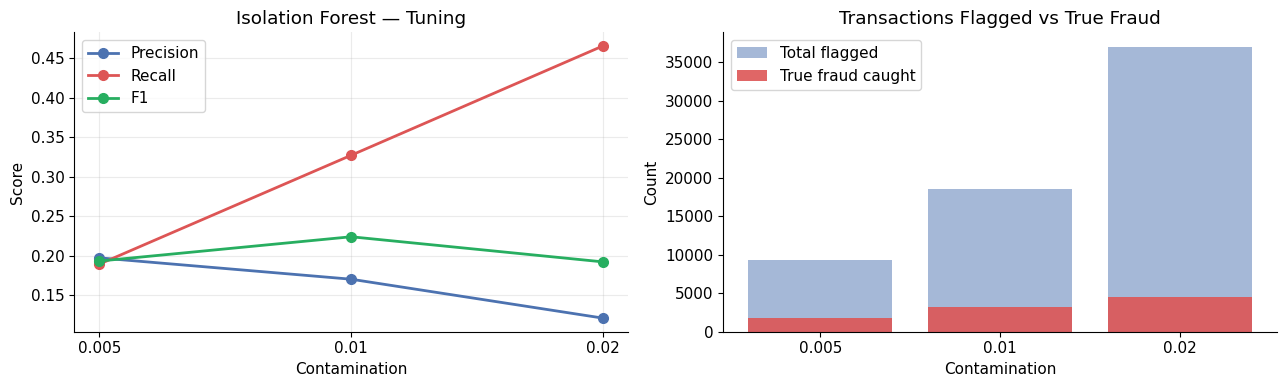

In [8]:
# Isolation Forest tuning chart
conts  = [r['contamination'] for r in if_results]
metric_names = ['precision', 'recall', 'f1']
colors = ['#4C72B0', '#DD5555', '#27AE60']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, color in zip(metric_names, colors):
    axes[0].plot([str(c) for c in conts], [r[name] for r in if_results],
                 'o-', label=name.capitalize(), color=color, linewidth=2, markersize=7)
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel('Score')
axes[0].set_title('Isolation Forest — Tuning')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# Flagged vs True Positive
axes[1].bar([str(c) for c in conts], [r['n_flagged'] for r in if_results],
             alpha=0.5, color='#4C72B0', label='Total flagged')
axes[1].bar([str(c) for c in conts], [r['tp'] for r in if_results],
             alpha=0.9, color='#DD5555', label='True fraud caught')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Count')
axes[1].set_title('Transactions Flagged vs True Fraud')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '20_isolation_forest_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2.5 Association Rule Mining — FP-Growth

In [9]:
# ── Threshold rationale ───────────────────────────────────────────────────────
# fraud_yes support = 0.521%  →  any rule A→fraud has support ≤ 0.521%
# min_support = 0.05% (0.0005) → captures itemsets in ≥ 926 transactions
# This means rules covering ≥ 9.6% of all fraud cases (926/9651)
# min_confidence kept low (0.01 = 1%) → we sort/filter by lift afterwards
MIN_SUPPORT_ARM = 0.0005   # 0.05%

print(f'min_support = {MIN_SUPPORT_ARM} ({MIN_SUPPORT_ARM*100:.3f}%)')
print(f'Min transaction count : {int(MIN_SUPPORT_ARM * N_TOTAL):,}')
print(f'Min fraud coverage    : {int(MIN_SUPPORT_ARM * N_TOTAL / N_FRAUD * 100):.1f}% of all fraud')
print(f'\nRunning FP-Growth on {N_TOTAL:,} transactions × {df_enc.shape[1]} items...')

t0 = time.time()
frequent_itemsets = fpgrowth(df_enc, min_support=MIN_SUPPORT_ARM,
                              use_colnames=True, verbose=0)
dt = time.time() - t0

print(f'Done in {dt:.1f}s')
print(f'Frequent itemsets found: {len(frequent_itemsets):,}')

size_dist = frequent_itemsets['itemsets'].apply(len).value_counts().sort_index()
print(f'\nItemset size distribution:')
for size, count in size_dist.items():
    print(f'  {size}-item sets : {count:,}')

min_support = 0.0005 (0.050%)
Min transaction count : 926
Min fraud coverage    : 9.0% of all fraud

Running FP-Growth on 1,852,394 transactions × 26 items...


Done in 4.4s
Frequent itemsets found: 902

Itemset size distribution:
  1-item sets : 26
  2-item sets : 184
  3-item sets : 428
  4-item sets : 264


In [10]:
# ── Generate association rules ─────────────────────────────────────────────────
# min_confidence = 0.01 (1% fraud rate) — will filter by lift afterwards
print('Generating association rules...')
t0 = time.time()

try:
    rules_raw = association_rules(
        frequent_itemsets, metric='confidence', min_threshold=0.01,
        num_itemsets=len(frequent_itemsets)
    )
except TypeError:
    rules_raw = association_rules(
        frequent_itemsets, metric='confidence', min_threshold=0.01
    )

print(f'Total rules generated : {len(rules_raw):,}  ({time.time()-t0:.1f}s)')

# ── Filter: consequent must be exactly {fraud_yes} ─────────────────────────────
fraud_rules = rules_raw[
    rules_raw['consequents'].apply(lambda x: x == frozenset({'fraud_yes'}))
].copy()

# ── Enrich with readable metrics ──────────────────────────────────────────────
fraud_rules['fraud_rate_%']   = (fraud_rules['confidence'] * 100).round(3)
fraud_rules['lift_x']         = (fraud_rules['confidence'] / FRAUD_RATE).round(1)
fraud_rules['antecedent_str'] = fraud_rules['antecedents'].apply(
    lambda x: ' AND '.join(sorted(x)))
fraud_rules['n_all_txn']      = (fraud_rules['antecedent support'] * N_TOTAL).astype(int)
fraud_rules['n_fraud_txn']    = (fraud_rules['support'] * N_TOTAL).astype(int)
fraud_rules['fraud_recall_%'] = (fraud_rules['n_fraud_txn'] / N_FRAUD * 100).round(2)

# Sort by lift
fraud_rules = fraud_rules.sort_values('lift_x', ascending=False).reset_index(drop=True)

print(f'\nRules with fraud_yes as consequent: {len(fraud_rules):,}')
print(f"Rules with lift ≥ 3x: {(fraud_rules['lift_x'] >= 3).sum()}")
print(f"Rules with lift ≥ 5x: {(fraud_rules['lift_x'] >= 5).sum()}")
print(f"Rules with lift ≥ 10x: {(fraud_rules['lift_x'] >= 10).sum()}")

Generating association rules...
Total rules generated : 5,779  (0.0s)

Rules with fraud_yes as consequent: 30
Rules with lift ≥ 3x: 25
Rules with lift ≥ 5x: 20
Rules with lift ≥ 10x: 17


In [11]:
# ── Top 25 rules — display ─────────────────────────────────────────────────────
display_cols = ['antecedent_str', 'fraud_rate_%', 'lift_x', 'n_fraud_txn',
                'fraud_recall_%', 'n_all_txn']
top25 = fraud_rules.head(25)
print('Top 25 Fraud Rules by Lift:')
print(top25[display_cols].to_string(index=True))

Top 25 Fraud Rules by Lift:
                                       antecedent_str  fraud_rate_%  lift_x  n_fraud_txn  fraud_recall_%  n_all_txn
0   amt_very_high AND cat_shopping_net AND time_night        63.704   122.3         1885           19.53       2959
1       amt_very_high AND cat_misc_net AND time_night        52.792   101.3         1021           10.58       1934
2         age_senior AND amt_very_high AND time_night        46.101    88.5         1478           15.31       3206
3                        amt_very_high AND time_night        46.032    88.4         3973           41.17       8631
4         age_middle AND amt_very_high AND time_night        42.338    81.3         1749           18.12       4131
5                      amt_very_high AND cat_misc_net        36.972    71.0         1182           12.25       3197
6                  amt_very_high AND cat_shopping_net        36.087    69.3         2219           22.99       6149
7                        age_senior AND amt_

---
## 2.6 Threshold Sensitivity Analysis

In [12]:
# Run FP-Growth at lower support to explore more rules
# (reuse existing frequent_itemsets, just filter by lift post-hoc)

print('Threshold sensitivity (using current frequent_itemsets):\n')
print(f'{"min_lift":>10} | {"n_rules":>8} | {"unique_fraud_covered":>20} | {"fraud_recall_%":>15} | {"avg_fraud_rate_%":>17}')
print('-' * 77)

sensitivity_rows = []
for min_lift in [2, 3, 5, 10, 20, 40]:
    sub = fraud_rules[fraud_rules['lift_x'] >= min_lift]
    if len(sub) == 0:
        print(f'{min_lift:>10} | {0:>8} | {"—":>20} | {"—":>15} | {"—":>17}')
        continue
    # Count unique fraud transactions covered by these rules
    covered = np.zeros(N_TOTAL, dtype=bool)
    for _, rule in sub.iterrows():
        ant = list(rule['antecedents'])
        covered |= df_enc[ant].all(axis=1).values
    n_fraud_covered = (covered & fraud_mask.values).sum()
    recall_pct      = n_fraud_covered / N_FRAUD * 100
    avg_rate        = sub['fraud_rate_%'].mean()
    sensitivity_rows.append({
        'min_lift': min_lift, 'n_rules': len(sub),
        'fraud_covered': n_fraud_covered, 'recall_%': recall_pct, 'avg_rate_%': avg_rate
    })
    print(f'{min_lift:>10} | {len(sub):>8} | {n_fraud_covered:>20,} | {recall_pct:>14.1f}% | {avg_rate:>16.2f}%')

sensitivity_df = pd.DataFrame(sensitivity_rows)

Threshold sensitivity (using current frequent_itemsets):

  min_lift |  n_rules | unique_fraud_covered |  fraud_recall_% |  avg_fraud_rate_%
-----------------------------------------------------------------------------
         2 |       30 |                9,323 |           96.6% |            17.69%


         3 |       25 |                8,288 |           85.9% |            20.96%
         5 |       20 |                7,315 |           75.8% |            25.71%
        10 |       17 |                7,262 |           75.2% |            29.59%


        20 |       15 |                7,256 |           75.2% |            32.52%
        40 |       11 |                6,669 |           69.1% |            39.07%


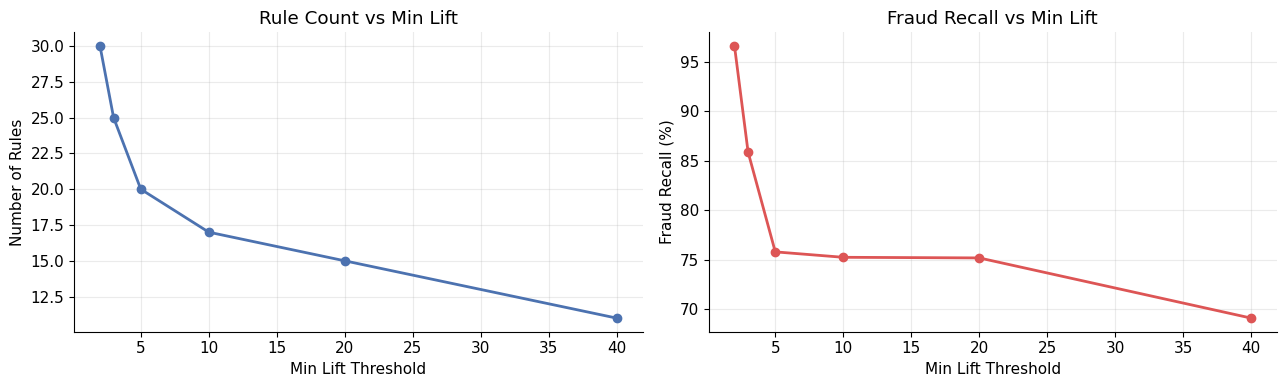

In [13]:
# Sensitivity chart
if len(sensitivity_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(sensitivity_df['min_lift'], sensitivity_df['n_rules'],
                 'o-', color='#4C72B0', linewidth=2)
    axes[0].set_xlabel('Min Lift Threshold')
    axes[0].set_ylabel('Number of Rules')
    axes[0].set_title('Rule Count vs Min Lift')
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(sensitivity_df['min_lift'], sensitivity_df['recall_%'],
                 'o-', color='#DD5555', linewidth=2)
    axes[1].set_xlabel('Min Lift Threshold')
    axes[1].set_ylabel('Fraud Recall (%)')
    axes[1].set_title('Fraud Recall vs Min Lift')
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(FIG_DIR + '21_threshold_sensitivity.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 2.7 Final Rules — Selection & Visualization

Final rules (lift ≥ 3x): 25


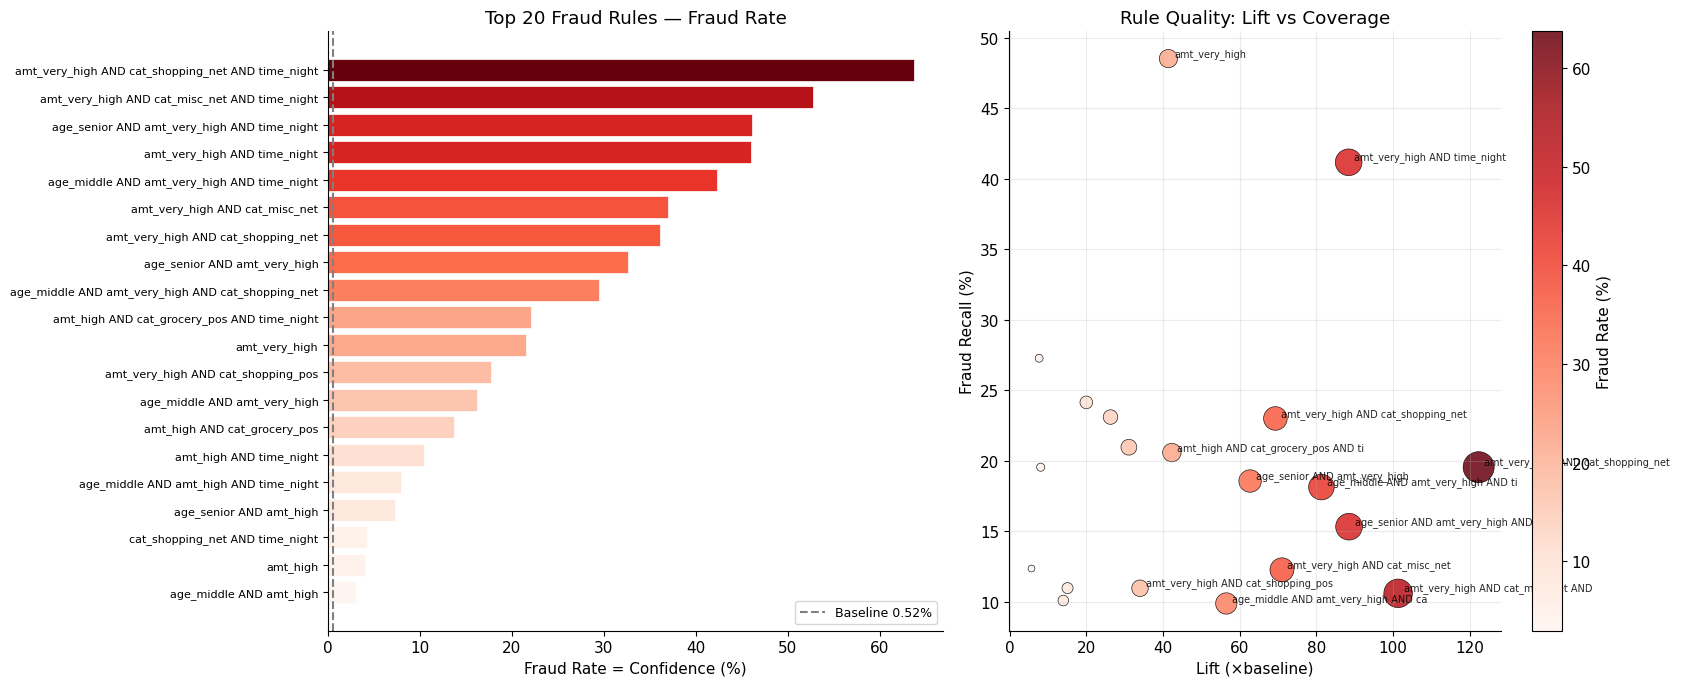

In [14]:
# ── Select final rule set: lift >= 3x baseline ─────────────────────────────────
# Rationale: 3x = fraud_rate > 1.56%, clear enough for analyst action;
# balances precision vs recall coverage
MIN_LIFT_FINAL = 3
final_rules = fraud_rules[fraud_rules['lift_x'] >= MIN_LIFT_FINAL].copy().reset_index(drop=True)
print(f'Final rules (lift ≥ {MIN_LIFT_FINAL}x): {len(final_rules)}')

# ── Visualize top 20 rules ─────────────────────────────────────────────────────
top20 = final_rules.head(20)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Chart 1: fraud rate per rule (bar)
colors_bar = plt.cm.Reds(
    (top20['fraud_rate_%'] - top20['fraud_rate_%'].min()) /
    (top20['fraud_rate_%'].max() - top20['fraud_rate_%'].min() + 1e-9)
)
axes[0].barh(range(len(top20)), top20['fraud_rate_%'],
             color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0].axvline(FRAUD_RATE * 100, color='gray', linestyle='--', linewidth=1.5,
                label=f'Baseline {FRAUD_RATE*100:.2f}%')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels([r[:55] for r in top20['antecedent_str']], fontsize=8)
axes[0].set_xlabel('Fraud Rate = Confidence (%)')
axes[0].set_title('Top 20 Fraud Rules — Fraud Rate')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Chart 2: lift vs fraud recall bubble
sc = axes[1].scatter(
    top20['lift_x'], top20['fraud_recall_%'],
    s=(top20['fraud_rate_%'] * 8).clip(20, 500),
    c=top20['fraud_rate_%'], cmap='Reds', alpha=0.85,
    edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, ax=axes[1], label='Fraud Rate (%)')
for i, row in top20.head(12).iterrows():
    axes[1].annotate(row['antecedent_str'][:35],
                     (row['lift_x'], row['fraud_recall_%']),
                     fontsize=7, alpha=0.85,
                     xytext=(4, 2), textcoords='offset points')
axes[1].set_xlabel('Lift (×baseline)')
axes[1].set_ylabel('Fraud Recall (%)')
axes[1].set_title('Rule Quality: Lift vs Coverage')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR + '22_top_fraud_rules.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# ── Plain-language rule interpretation (top 15) ────────────────────────────────
print('=' * 80)
print('  FRAUD RULES — PLAIN LANGUAGE INTERPRETATION')
print('=' * 80)
print(f'  Baseline fraud rate: {FRAUD_RATE*100:.4f}%\n')

for i, row in final_rules.head(15).iterrows():
    # Build human-readable condition
    parts = sorted(row['antecedents'])
    conditions = []
    for p in parts:
        if p.startswith('cat_'):  conditions.append(f"category={p[4:]}")
        elif p == 'amt_very_high': conditions.append('amount > $500')
        elif p == 'amt_high':      conditions.append('amount $200–500')
        elif p == 'amt_medium':    conditions.append('amount $50–200')
        elif p == 'amt_low':       conditions.append('amount < $50')
        elif p == 'time_night':    conditions.append('time 22:00–06:00')
        elif p == 'time_morning':  conditions.append('time 06:00–12:00')
        elif p == 'time_afternoon':conditions.append('time 12:00–18:00')
        elif p == 'time_evening':  conditions.append('time 18:00–22:00')
        elif p == 'age_senior':    conditions.append('cardholder age > 55')
        elif p == 'age_middle':    conditions.append('cardholder age 30–55')
        elif p == 'age_young':     conditions.append('cardholder age < 30')
        else: conditions.append(p)

    cond_str = ' AND '.join(conditions)
    print(f'Rule #{i+1}: IF {cond_str}')
    print(f'        → Fraud rate: {row["fraud_rate_%"]:.2f}%  '
          f'| Lift: {row["lift_x"]:.1f}x  '
          f'| Covers: {row["n_fraud_txn"]:,} fraud txn ({row["fraud_recall_%"]:.1f}% recall)  '
          f'| All txn in pattern: {row["n_all_txn"]:,}')
    print()

  FRAUD RULES — PLAIN LANGUAGE INTERPRETATION
  Baseline fraud rate: 0.5210%

Rule #1: IF amount > $500 AND category=shopping_net AND time 22:00–06:00
        → Fraud rate: 63.70%  | Lift: 122.3x  | Covers: 1,885 fraud txn (19.5% recall)  | All txn in pattern: 2,959

Rule #2: IF amount > $500 AND category=misc_net AND time 22:00–06:00
        → Fraud rate: 52.79%  | Lift: 101.3x  | Covers: 1,021 fraud txn (10.6% recall)  | All txn in pattern: 1,934

Rule #3: IF cardholder age > 55 AND amount > $500 AND time 22:00–06:00
        → Fraud rate: 46.10%  | Lift: 88.5x  | Covers: 1,478 fraud txn (15.3% recall)  | All txn in pattern: 3,206

Rule #4: IF amount > $500 AND time 22:00–06:00
        → Fraud rate: 46.03%  | Lift: 88.4x  | Covers: 3,973 fraud txn (41.2% recall)  | All txn in pattern: 8,631

Rule #5: IF cardholder age 30–55 AND amount > $500 AND time 22:00–06:00
        → Fraud rate: 42.34%  | Lift: 81.3x  | Covers: 1,749 fraud txn (18.1% recall)  | All txn in pattern: 4,131

Rule #6:

---
## 2.8 Flag Transactions Using Final Rules

In [16]:
# Build rule-flagging function
def flag_by_rules(rules_df, enc_df):
    """Returns bool array: True if transaction matches any rule's antecedent."""
    flagged = np.zeros(len(enc_df), dtype=bool)
    for _, rule in rules_df.iterrows():
        ant = list(rule['antecedents'])
        flagged |= enc_df[ant].all(axis=1).values
    return flagged

print('Flagging transactions using final rules...')
t0 = time.time()
y_pred_rules = flag_by_rules(final_rules, df_enc).astype(int)
print(f'Done in {time.time()-t0:.1f}s')

prec_r  = precision_score(y_true, y_pred_rules)
rec_r   = recall_score(y_true, y_pred_rules)
f1_r    = f1_score(y_true, y_pred_rules)
ap_r    = average_precision_score(y_true, y_pred_rules)
n_flag_r = y_pred_rules.sum()
tp_r     = ((y_pred_rules == 1) & (y_true == 1)).sum()
fp_r     = ((y_pred_rules == 1) & (y_true == 0)).sum()

print(f'\n── Association Rules (lift ≥ {MIN_LIFT_FINAL}x) ──')
print(f'Rules used           : {len(final_rules)}')
print(f'Transactions flagged : {n_flag_r:,} ({n_flag_r/N_TOTAL*100:.2f}% of all)')
print(f'True Positives       : {tp_r:,} / {N_FRAUD:,} ({tp_r/N_FRAUD*100:.1f}% recall)')
print(f'False Positives      : {fp_r:,}')
print(f'Precision            : {prec_r:.4f} ({prec_r*100:.2f}%)')
print(f'Recall               : {rec_r:.4f} ({rec_r*100:.2f}%)')
print(f'F1-Score             : {f1_r:.4f}')
print(f'AUC-PR               : {ap_r:.4f}')

Flagging transactions using final rules...
Done in 0.1s



── Association Rules (lift ≥ 3x) ──
Rules used           : 25
Transactions flagged : 510,240 (27.54% of all)
True Positives       : 8,288 / 9,651 (85.9% recall)
False Positives      : 501,952
Precision            : 0.0162 (1.62%)
Recall               : 0.8588 (85.88%)
F1-Score             : 0.0319
AUC-PR               : 0.0147


---
## 2.9 Overlap Analysis — Rules vs Isolation Forest

── Fraud Transaction Coverage ──
Total fraud          : 9,651
Both methods catch   : 3,151 (32.6%)
Only rules catch     : 5,137 (53.2%)  ← rule advantage
Only IF catches      : 5 (0.1%)    ← anomaly advantage
Neither catches      : 1,358 (14.1%)


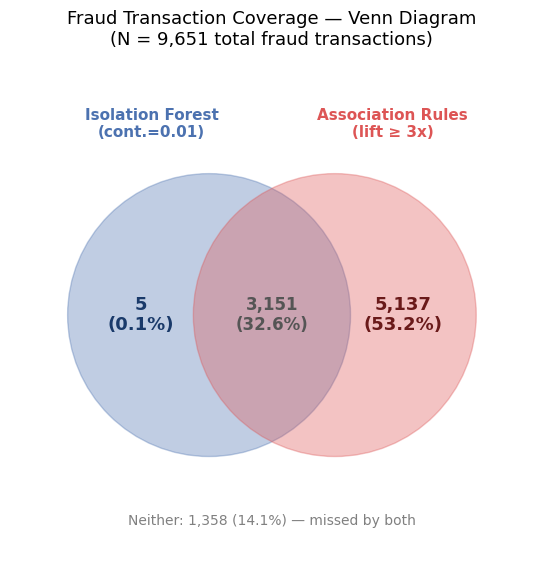

In [17]:
# Compute overlap on FRAUD transactions only
rules_flag_fraud = (y_pred_rules == 1) & (y_true == 1)   # caught by rules
if_flag_fraud    = (y_pred_if_best == 1) & (y_true == 1)  # caught by IF

both_caught  = (rules_flag_fraud & if_flag_fraud).sum()
only_rules   = (rules_flag_fraud & ~if_flag_fraud).sum()
only_if      = (~rules_flag_fraud & if_flag_fraud).sum()
neither      = N_FRAUD - both_caught - only_rules - only_if  # fraud not caught by either

print('── Fraud Transaction Coverage ──')
print(f'Total fraud          : {N_FRAUD:,}')
print(f'Both methods catch   : {both_caught:,} ({both_caught/N_FRAUD*100:.1f}%)')
print(f'Only rules catch     : {only_rules:,} ({only_rules/N_FRAUD*100:.1f}%)  ← rule advantage')
print(f'Only IF catches      : {only_if:,} ({only_if/N_FRAUD*100:.1f}%)    ← anomaly advantage')
print(f'Neither catches      : {neither:,} ({neither/N_FRAUD*100:.1f}%)')

# ── Venn diagram (manual) ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')

# Draw circles
c1 = plt.Circle((0.38, 0.5), 0.27, alpha=0.35, color='#4C72B0')
c2 = plt.Circle((0.62, 0.5), 0.27, alpha=0.35, color='#DD5555')
ax.add_patch(c1)
ax.add_patch(c2)

# Labels inside circles
ax.text(0.25, 0.5, f'{only_if:,}\n({only_if/N_FRAUD*100:.1f}%)',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#1a3a6a')
ax.text(0.5,  0.5, f'{both_caught:,}\n({both_caught/N_FRAUD*100:.1f}%)',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#555')
ax.text(0.75, 0.5, f'{only_rules:,}\n({only_rules/N_FRAUD*100:.1f}%)',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#6a1a1a')

# Labels outside
ax.text(0.27, 0.84, f'Isolation Forest\n(cont.={best_if["contamination"]})',
        ha='center', fontsize=11, color='#4C72B0', fontweight='bold')
ax.text(0.73, 0.84, f'Association Rules\n(lift ≥ {MIN_LIFT_FINAL}x)',
        ha='center', fontsize=11, color='#DD5555', fontweight='bold')

# Neither box
ax.text(0.5, 0.1, f'Neither: {neither:,} ({neither/N_FRAUD*100:.1f}%) — missed by both',
        ha='center', fontsize=10, color='gray')

ax.set_title(f'Fraud Transaction Coverage — Venn Diagram\n'
             f'(N = {N_FRAUD:,} total fraud transactions)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR + '23_venn_overlap.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# What does IF catch that rules miss?
if_only_mask    = ~rules_flag_fraud & if_flag_fraud
rules_only_mask = rules_flag_fraud & ~if_flag_fraud

def describe_group(mask, label):
    if mask.sum() == 0:
        print(f'{label}: none')
        return
    sub = df[mask]
    print(f'{label}  (n={len(sub):,})')
    print(f'  amt median   : ${sub["amt"].median():.2f}')
    print(f'  distance_km  : {sub["distance_km"].median():.1f} km')
    print(f'  age median   : {sub["age"].median():.0f}')
    night_pct = sub['hour_of_day'].apply(lambda h: h >= 22 or h < 6).mean() * 100
    print(f'  night %      : {night_pct:.1f}%')
    print(f'  top category : {sub["category"].value_counts().index[0]}')
    print()

describe_group(if_only_mask,    '-- Only Isolation Forest catches --')
describe_group(rules_only_mask, '-- Only Rules catch --')


-- Only Isolation Forest catches --  (n=5)
  amt median   : $19.00
  distance_km  : 74.4 km
  age median   : 36
  night %      : 100.0%
  top category : health_fitness

-- Only Rules catch --  (n=5,137)
  amt median   : $321.37
  distance_km  : 77.8 km
  age median   : 47
  night %      : 86.5%
  top category : grocery_pos



---
## 2.10 Final Comparison — All 3 Methods

In [19]:
# Build comparison DataFrame
comparison = pd.DataFrame([
    {
        'Method'         : 'Baseline: amt > $500',
        'Description'    : 'Simple threshold rule',
        'Precision'      : prec_t,
        'Recall'         : rec_t,
        'F1'             : f1_t,
        'AUC-PR'         : ap_t,
        'Flagged'        : y_pred_thresh.sum(),
        'TruePositives'  : tp_t,
    },
    {
        'Method'         : f'Isolation Forest (cont={best_if["contamination"]})',
        'Description'    : 'Unsupervised anomaly detection',
        'Precision'      : best_if['precision'],
        'Recall'         : best_if['recall'],
        'F1'             : best_if['f1'],
        'AUC-PR'         : best_if['ap'],
        'Flagged'        : best_if['n_flagged'],
        'TruePositives'  : best_if['tp'],
    },
    {
        'Method'         : f'Assoc. Rules (lift ≥ {MIN_LIFT_FINAL}x)',
        'Description'    : f'{len(final_rules)} interpretable fraud rules',
        'Precision'      : prec_r,
        'Recall'         : rec_r,
        'F1'             : f1_r,
        'AUC-PR'         : ap_r,
        'Flagged'        : n_flag_r,
        'TruePositives'  : tp_r,
    },
])

# Display
print('=' * 90)
print('  METHOD COMPARISON — Phase 2')
print('=' * 90)
for _, row in comparison.iterrows():
    print(f"\n{row['Method']}  [{row['Description']}]")
    print(f"  Precision : {row['Precision']:.4f} ({row['Precision']*100:.2f}%)")
    print(f"  Recall    : {row['Recall']:.4f} ({row['Recall']*100:.2f}%)")
    print(f"  F1-Score  : {row['F1']:.4f}")
    print(f"  AUC-PR    : {row['AUC-PR']:.4f}")
    print(f"  Flagged   : {int(row['Flagged']):,} transactions")
    print(f"  True +    : {int(row['TruePositives']):,} / {N_FRAUD:,} fraud ({row['TruePositives']/N_FRAUD*100:.1f}%)")
print()

  METHOD COMPARISON — Phase 2

Baseline: amt > $500  [Simple threshold rule]
  Precision : 0.2158 (21.58%)
  Recall    : 0.4853 (48.53%)
  F1-Score  : 0.2987
  AUC-PR    : 0.1074
  Flagged   : 21,709 transactions
  True +    : 4,684 / 9,651 fraud (48.5%)

Isolation Forest (cont=0.01)  [Unsupervised anomaly detection]
  Precision : 0.1704 (17.04%)
  Recall    : 0.3270 (32.70%)
  F1-Score  : 0.2240
  AUC-PR    : 0.0592
  Flagged   : 18,524 transactions
  True +    : 3,156 / 9,651 fraud (32.7%)

Assoc. Rules (lift ≥ 3x)  [25 interpretable fraud rules]
  Precision : 0.0162 (1.62%)
  Recall    : 0.8588 (85.88%)
  F1-Score  : 0.0319
  AUC-PR    : 0.0147
  Flagged   : 510,240 transactions
  True +    : 8,288 / 9,651 fraud (85.9%)



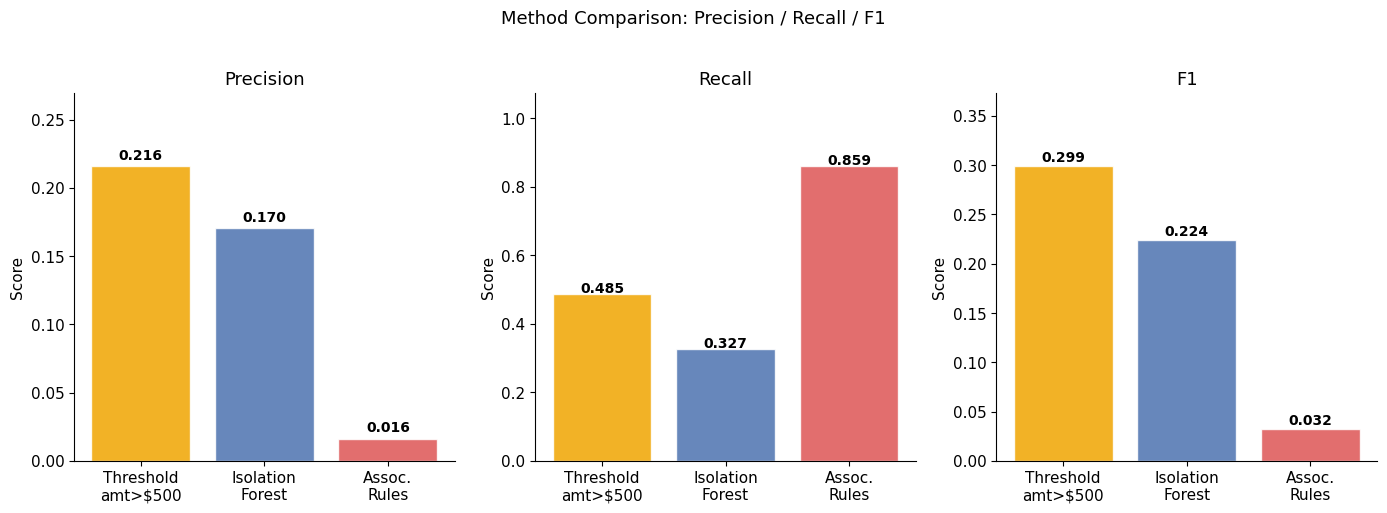

In [20]:
# Comparison chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
methods   = ['Threshold\namt>$500', f'Isolation\nForest', f'Assoc.\nRules']
colors    = ['#F0A500', '#4C72B0', '#DD5555']

for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    vals = comparison[metric].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel('Score')

plt.suptitle('Method Comparison: Precision / Recall / F1', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + '24_method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2.11 Rule Summary Table — Analyst-Ready

In [21]:
# Build analyst-ready summary with plain English action
def build_plain_condition(antecedents):
    parts = []
    for p in sorted(antecedents):
        if p.startswith('cat_'):   parts.append(f"category={p[4:]}")
        elif p == 'amt_very_high': parts.append('amt>$500')
        elif p == 'amt_high':      parts.append('amt $200-500')
        elif p == 'amt_medium':    parts.append('amt $50-200')
        elif p == 'amt_low':       parts.append('amt<$50')
        elif p == 'time_night':    parts.append('night(22-6)')
        elif p == 'time_morning':  parts.append('morning(6-12)')
        elif p == 'time_afternoon':parts.append('afternoon(12-18)')
        elif p == 'time_evening':  parts.append('evening(18-22)')
        elif p == 'age_senior':    parts.append('age>55')
        elif p == 'age_middle':    parts.append('age 30-55')
        elif p == 'age_young':     parts.append('age<30')
        else: parts.append(p)
    return ' AND '.join(parts)

def analyst_action(row):
    if row['fraud_rate_%'] >= 50:   return 'BLOCK — high confidence fraud'
    if row['fraud_rate_%'] >= 20:   return 'HOLD for manual review'
    if row['fraud_rate_%'] >= 5:    return 'FLAG — escalate to analyst'
    return 'MONITOR — log and watch'

summary_table = final_rules.copy()
summary_table['condition'] = summary_table['antecedents'].apply(build_plain_condition)
summary_table['action']    = summary_table.apply(analyst_action, axis=1)
summary_table['support_%'] = (summary_table['antecedent support'] * 100).round(3)

output_cols = ['condition', 'support_%', 'fraud_rate_%', 'lift_x',
               'n_fraud_txn', 'fraud_recall_%', 'action']
analyst_df  = summary_table[output_cols].copy()

print('FRAUD RULE SUMMARY — Analyst Action Table')
print(analyst_df.to_string(index=True))

FRAUD RULE SUMMARY — Analyst Action Table
                                                condition  support_%  fraud_rate_%  lift_x  n_fraud_txn  fraud_recall_%                         action
0      amt>$500 AND category=shopping_net AND night(22-6)      0.160        63.704   122.3         1885           19.53  BLOCK — high confidence fraud
1          amt>$500 AND category=misc_net AND night(22-6)      0.104        52.792   101.3         1021           10.58  BLOCK — high confidence fraud
2                     age>55 AND amt>$500 AND night(22-6)      0.173        46.101    88.5         1478           15.31         HOLD for manual review
3                                amt>$500 AND night(22-6)      0.466        46.032    88.4         3973           41.17         HOLD for manual review
4                  age 30-55 AND amt>$500 AND night(22-6)      0.223        42.338    81.3         1749           18.12         HOLD for manual review
5                          amt>$500 AND category=mis

---
## 2.12 Save Outputs

In [22]:
# ── Save final rule table ──────────────────────────────────────────────────────
analyst_df.to_csv(RULES_DIR + 'fraud_rules_final.csv', index=True)
print(f'Saved: {RULES_DIR}fraud_rules_final.csv  ({len(analyst_df)} rules)')

# ── Save comparison table ──────────────────────────────────────────────────────
comparison.to_csv(RULES_DIR + 'method_comparison.csv', index=False)
print(f'Saved: {RULES_DIR}method_comparison.csv')

# ── Save flagging columns back to processed data ───────────────────────────────
df['flag_threshold'] = y_pred_thresh
df['flag_iso_forest'] = y_pred_if_best
df['flag_rules']     = y_pred_rules

df.to_csv('../data/processed/transactions_phase2.csv', index=False)
print(f'Saved: ../data/processed/transactions_phase2.csv  ({df.shape})')

# ── Summary printout ──────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('  PHASE 2 COMPLETE')
print('=' * 60)
print(f'  Total fraud          : {N_FRAUD:,} ({FRAUD_RATE*100:.4f}%)')
print(f'  Final rules selected : {len(final_rules)} (lift ≥ {MIN_LIFT_FINAL}x)')
print(f'  Rules P/R/F1         : {prec_r:.3f} / {rec_r:.3f} / {f1_r:.3f}')
print(f'  Best IF P/R/F1       : {best_if["precision"]:.3f} / {best_if["recall"]:.3f} / {best_if["f1"]:.3f}')
print(f'  Threshold P/R/F1     : {prec_t:.3f} / {rec_t:.3f} / {f1_t:.3f}')
print(f'  Overlap: both catch  : {both_caught:,} ({both_caught/N_FRAUD*100:.1f}%)')
print(f'  Rule-only advantage  : {only_rules:,} ({only_rules/N_FRAUD*100:.1f}%)')
print(f'  IF-only advantage    : {only_if:,} ({only_if/N_FRAUD*100:.1f}%)')
print(f'  Neither catches      : {neither:,} ({neither/N_FRAUD*100:.1f}%)')
print('=' * 60)

Saved: ../outputs/rules/fraud_rules_final.csv  (25 rules)
Saved: ../outputs/rules/method_comparison.csv


Saved: ../data/processed/transactions_phase2.csv  ((1852394, 38))

  PHASE 2 COMPLETE
  Total fraud          : 9,651 (0.5210%)
  Final rules selected : 25 (lift ≥ 3x)
  Rules P/R/F1         : 0.016 / 0.859 / 0.032
  Best IF P/R/F1       : 0.170 / 0.327 / 0.224
  Threshold P/R/F1     : 0.216 / 0.485 / 0.299
  Overlap: both catch  : 3,151 (32.6%)
  Rule-only advantage  : 5,137 (53.2%)
  IF-only advantage    : 5 (0.1%)
  Neither catches      : 1,358 (14.1%)
